# Fatigue KPI — feature research

**Goal.** Identify the smallest, most interpretable feature set that predicts the
dataset's ground-truth `creative_status == "fatigued"` label and approximates
`fatigue_day`, *without* consuming either column at inference.

**Why this matters.** The production fatigue endpoint
(`backend/app/services/fatigue.py`) ships a logistic-regression head over a handful
of engineered features. Smadex feedback was that the health KPI needs explicit
empirical backing — *which* features, *how much* signal each carries, and how the
combined model compares to the dataset's own pre-computed `ctr_decay_pct` baseline.

**Method.**

1. Load the seven CSVs and join into one master frame at the (creative) grain.
2. Engineer per-creative time-series features: anchor-period CTRs, drop ratio,
   linear slope, peak-to-last drawdown, binomial-likelihood-ratio changepoint.
3. Add cohort-relative features (vertical × format) and pull in the static
   creative metadata + Smadex's pre-computed columns.
4. Univariate ranking: per-feature ROC-AUC, mutual information, Cohen's d.
5. **Campaign-grouped** train/test split (so a campaign's six creatives never
   straddle the split — prevents cohort leakage).
6. Compare four classical models (logistic regression, random forest, two
   HistGradientBoosting depths) by 5-fold grouped CV.
7. Permutation importance + SHAP on the winning model. Ablate by feature group
   to size where the signal lives.
8. Mini-regression on `fatigue_day` (only on fatigued creatives) to size how
   tightly we can locate the breakpoint.

**Out of scope.** Image embeddings (CLIP runs in the production codebase but
adds nothing measurable to the fatigue label, which is purely a function of the
daily CTR series) and any deep-learning model.


In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import (
    GradientBoostingRegressor,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    roc_auc_score,
)
from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    cross_val_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

DATA_DIR = Path("../resources/smadex/Smadex_Creative_Intelligence_Dataset_FULL")
RANDOM_STATE = 42


In [2]:
advertisers = pd.read_csv(DATA_DIR / "advertisers.csv")
campaigns   = pd.read_csv(DATA_DIR / "campaigns.csv", parse_dates=["start_date", "end_date"])
creatives   = pd.read_csv(DATA_DIR / "creatives.csv", parse_dates=["creative_launch_date"])
daily       = pd.read_csv(DATA_DIR / "creative_daily_country_os_stats.csv", parse_dates=["date"])
cr_summary  = pd.read_csv(DATA_DIR / "creative_summary.csv", parse_dates=["creative_launch_date"])

print("advertisers:", advertisers.shape)
print("campaigns:  ", campaigns.shape)
print("creatives:  ", creatives.shape)
print("daily:      ", daily.shape)
print("summary:    ", cr_summary.shape)


advertisers: (36, 4)
campaigns:   (180, 14)
creatives:   (1080, 32)
daily:       (192315, 14)
summary:     (1080, 59)


## 1. Class balance and label sanity

We want to know up front: how skewed is the fatigue label, and does
`fatigue_day` line up exactly with `creative_status == "fatigued"`?


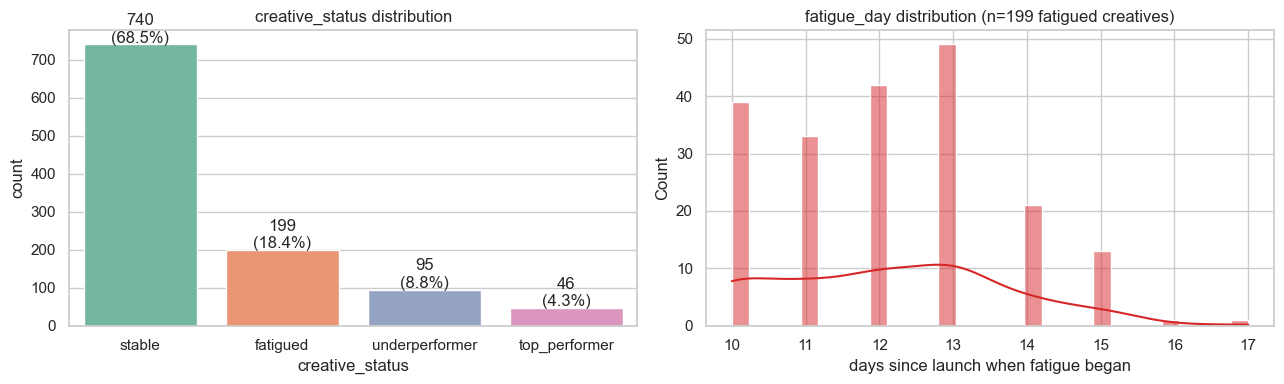


fatigue_day non-null iff status=='fatigued': True

fatigue_day stats:
count    199.0
mean      12.1
std        1.6
min       10.0
25%       11.0
50%       12.0
75%       13.0
max       17.0
Name: fatigue_day, dtype: float64

base rate of fatigued creatives: 18.4%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

status_counts = cr_summary["creative_status"].value_counts()
sns.barplot(x=status_counts.index, y=status_counts.values, ax=axes[0],
            hue=status_counts.index, palette="Set2", legend=False)
axes[0].set_title("creative_status distribution")
axes[0].set_ylabel("count")
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 5, f"{v}\n({v / len(cr_summary):.1%})", ha="center")

fat = cr_summary[cr_summary["fatigue_day"].notna()]
sns.histplot(fat["fatigue_day"], bins=30, ax=axes[1], kde=True, color="#d62728")
axes[1].set_title(f"fatigue_day distribution (n={len(fat)} fatigued creatives)")
axes[1].set_xlabel("days since launch when fatigue began")

plt.tight_layout(); plt.show()

aligned = (cr_summary["fatigue_day"].notna() == (cr_summary["creative_status"] == "fatigued")).all()
print(f"\nfatigue_day non-null iff status=='fatigued': {aligned}")
print(f"\nfatigue_day stats:\n{fat['fatigue_day'].describe().round(1)}")
print(f"\nbase rate of fatigued creatives: {(cr_summary['creative_status']=='fatigued').mean():.1%}")


## 2. Build the per-creative time series

The daily fact table is at the (date × creative × country × OS) grain. Fatigue is
a property of the creative, so we collapse country and OS first.


In [4]:
ts = (
    daily.groupby(["creative_id", "date"], as_index=False)
         .agg(impressions=("impressions", "sum"),
              clicks=("clicks", "sum"),
              conversions=("conversions", "sum"),
              spend_usd=("spend_usd", "sum"),
              revenue_usd=("revenue_usd", "sum"),
              days_since_launch=("days_since_launch", "first"))
         .sort_values(["creative_id", "date"])
         .reset_index(drop=True)
)
ts["ctr"] = ts["clicks"] / ts["impressions"].clip(lower=1)
print("ts shape:", ts.shape)
ts.head()


ts shape: (52349, 9)


,creative_id,date,impressions,clicks,conversions,spend_usd,revenue_usd,days_since_launch,ctr
0,500000,2026-01-19,940460,10626,2156,5917.42,11713.79,0,0.011299
1,500000,2026-01-20,450862,4302,905,2669.38,4990.81,1,0.009542
2,500000,2026-01-21,455904,3924,721,2804.97,4024.43,2,0.008607
3,500000,2026-01-22,347661,2831,550,2202.00,2832.93,3,0.008143
4,500000,2026-01-23,380006,2475,467,2332.58,2374.40,4,0.006513


## 3. Engineered time-series features

For each creative, build features that capture the *shape* of the daily CTR
series:

- **anchor-period rates** (`p_first`, `p_last`) — mean CTR over the first / last
  ~7 active days. These are computed as sum-of-clicks / sum-of-impressions, not
  a mean of daily ratios, so they're not biased by zero-impression days.
- **`drop_ratio = p_last / p_first`** — the run-over-run drop.
- **`ctr_slope`** — OLS slope of daily CTR vs day index (negative = decay).
- **`peak_to_last_drawdown`** — ratio of the final 7-day rolling CTR to its peak
  during the creative's lifetime. Captures decline from a personal-best high.
- **`lr_stat` / `best_k`** — MLE binomial changepoint scan. For each candidate
  split point `k`, fit independent rates for `[:k]` and `[k:]` and compute the
  likelihood ratio against the no-split null. Pick `k` that maximises LR. This
  is the same statistic shipped in the production endpoint.
- **volume + variance gates** — `log_total_impr`, `ctr_cv`, `days_active`.


In [5]:
def _changepoint_lr(impr: np.ndarray, clk: np.ndarray, min_pre: int = 7, min_post: int = 7):
    """MLE binomial changepoint scan. Returns (best_k, LR, p_pre, p_post) or None."""
    n = len(impr)
    cum_imp = np.cumsum(impr)
    cum_clk = np.cumsum(clk)
    total_imp, total_clk = cum_imp[-1], cum_clk[-1]
    if total_imp <= 0 or total_clk <= 0:
        return None
    p0 = total_clk / total_imp
    if not (0 < p0 < 1):
        return None
    ll0 = total_clk * np.log(p0) + (total_imp - total_clk) * np.log(1 - p0)
    best = (-1, -np.inf, 0.0, 0.0)
    for k in range(min_pre, n - min_post + 1):
        pre_imp, pre_clk = cum_imp[k - 1], cum_clk[k - 1]
        post_imp, post_clk = total_imp - pre_imp, total_clk - pre_clk
        if pre_imp <= 0 or post_imp <= 0:
            continue
        p1, p2 = pre_clk / pre_imp, post_clk / post_imp
        if not (0 < p1 < 1 and 0 < p2 < 1) or p2 >= p1:
            continue
        ll = (pre_clk * np.log(p1) + (pre_imp - pre_clk) * np.log(1 - p1)
              + post_clk * np.log(p2) + (post_imp - post_clk) * np.log(1 - p2))
        lr = 2.0 * (ll - ll0)
        if lr > best[1]:
            best = (k, lr, p1, p2)
    return None if best[0] < 0 else best


def ts_features(g: pd.DataFrame) -> dict:
    impr = g["impressions"].to_numpy(float)
    clk = g["clicks"].to_numpy(float)
    n = len(impr)
    out = {"creative_id": int(g["creative_id"].iloc[0]), "n_days": n}
    if n < 14 or impr.sum() <= 0 or clk.sum() <= 0:
        return out

    daily_ctr = np.where(impr > 0, clk / np.maximum(impr, 1), 0.0)
    n_anchor = min(7, n // 3)
    f_imp, f_clk = impr[:n_anchor].sum(), clk[:n_anchor].sum()
    l_imp, l_clk = impr[-n_anchor:].sum(), clk[-n_anchor:].sum()

    out["p_first"] = float(f_clk / f_imp) if f_imp > 0 else 0.0
    out["p_last"]  = float(l_clk / l_imp) if l_imp > 0 else 0.0
    out["drop_ratio"] = (out["p_last"] / out["p_first"]) if out["p_first"] > 0 else 1.0
    out["log_total_impr"] = float(np.log1p(impr.sum()))
    out["ctr_mean"] = float(daily_ctr.mean())
    out["ctr_std"]  = float(daily_ctr.std())
    out["ctr_cv"]   = float(out["ctr_std"] / max(out["ctr_mean"], 1e-9))
    out["days_active"] = float(n)

    x = np.arange(n, dtype=float)
    if daily_ctr.std() > 0:
        slope = float(np.polyfit(x, daily_ctr, 1)[0])
    else:
        slope = 0.0
    out["ctr_slope"] = slope

    s = pd.Series(daily_ctr).rolling(7, min_periods=1).mean()
    peak = float(s.max())
    out["peak_to_last_drawdown"] = float(s.iloc[-1] / peak) if peak > 0 else 1.0

    cp = _changepoint_lr(impr, clk)
    if cp is None:
        out["lr_stat"] = 0.0
        out["best_k"]  = float("nan")
        out["p_pre"]   = out["p_first"]
        out["p_post"]  = out["p_last"]
    else:
        k, lr, p_pre, p_post = cp
        out["lr_stat"] = float(lr)
        out["best_k"]  = float(k)
        out["p_pre"]   = float(p_pre)
        out["p_post"]  = float(p_post)
    return out


feats_ts = pd.DataFrame([ts_features(g) for _, g in ts.groupby("creative_id")])
print("feats_ts shape:", feats_ts.shape)
feats_ts.head()


feats_ts shape: (1080, 16)


,creative_id,n_days,p_first,p_last,drop_ratio,log_total_impr,ctr_mean,ctr_std,ctr_cv,days_active,ctr_slope,peak_to_last_drawdown,lr_stat,best_k,p_pre,p_post
0,500000,57,0.008469,0.001818,0.214709,16.271367,0.002701,0.002107,0.780120,57.0,-0.000081,0.161486,22045.778667,8.0,0.008131,0.001978
1,500001,46,0.015090,0.001825,0.120953,15.657466,0.006423,0.004696,0.731153,46.0,-0.000333,0.118320,17301.744355,16.0,0.012446,0.003368
2,500002,42,0.016044,0.001867,0.116379,15.515279,0.007012,0.005109,0.728496,42.0,-0.000400,0.112236,15862.048431,18.0,0.012244,0.003172
3,500003,54,0.012618,0.001787,0.141612,16.072501,0.004432,0.003664,0.826645,54.0,-0.000201,0.125897,26438.357419,13.0,0.010972,0.002555
4,500004,56,0.013378,0.001820,0.136029,15.906855,0.004458,0.003875,0.869085,56.0,-0.000200,0.124402,25052.200925,13.0,0.011473,0.002520


## 4. Cohort-relative features

A single creative's CTR is hard to interpret in isolation — a fintech banner CTR
of 0.4% is healthy; for a gaming playable it would be a disaster. Cohort the
creatives by `(vertical, format)` and express each one relative to its cohort.


In [6]:
cohort_keys = creatives[["creative_id", "vertical", "format", "campaign_id"]]
feats_ts = feats_ts.merge(cohort_keys, on="creative_id", how="left")

cohort_first = feats_ts.groupby(["vertical", "format"])["p_first"].median().rename("cohort_first_median")
cohort_last  = feats_ts.groupby(["vertical", "format"])["p_last"].quantile(0.25).rename("cohort_last_p25")
cohort_drop  = feats_ts.groupby(["vertical", "format"])["drop_ratio"].median().rename("cohort_drop_median")

feats_ts = (
    feats_ts.merge(cohort_first, on=["vertical", "format"], how="left")
            .merge(cohort_last,  on=["vertical", "format"], how="left")
            .merge(cohort_drop,  on=["vertical", "format"], how="left")
)
feats_ts["first_vs_cohort"] = feats_ts["p_first"]    / feats_ts["cohort_first_median"].clip(lower=1e-9)
feats_ts["last_vs_cohort"]  = feats_ts["p_last"]     / feats_ts["cohort_last_p25"].clip(lower=1e-9)
feats_ts["drop_vs_cohort"]  = feats_ts["drop_ratio"] / feats_ts["cohort_drop_median"].clip(lower=1e-9)

feats_ts[["vertical", "format", "cohort_first_median", "cohort_last_p25", "cohort_drop_median"]].drop_duplicates().head(10)


,vertical,format,cohort_first_median,cohort_last_p25,cohort_drop_median
0,gaming,interstitial,0.013666,0.001787,0.141612
1,gaming,rewarded_video,0.015846,0.001822,0.141949
6,ecommerce,banner,0.007773,0.001778,0.249245
7,ecommerce,interstitial,0.011406,0.001772,0.175276
8,ecommerce,native,0.009509,0.001788,0.201767
12,fintech,native,0.006976,0.001773,0.269418
13,fintech,banner,0.006076,0.001777,0.308816
16,fintech,interstitial,0.008114,0.001794,0.247843
18,travel,rewarded_video,0.013016,0.001869,0.179507
19,travel,interstitial,0.011496,0.001792,0.179029


## 5. Master frame

Join the engineered features with: static creative metadata, Smadex's
pre-computed summary columns (which we'll compare against as a baseline), and
the ground-truth labels.


In [7]:
static_cols = [
    "creative_id", "vertical", "format", "theme", "hook_type", "dominant_color",
    "emotional_tone", "duration_sec", "text_density", "readability_score",
    "brand_visibility_score", "clutter_score", "novelty_score", "motion_score",
    "faces_count", "product_count", "has_price", "has_discount_badge",
    "has_gameplay", "has_ugc_style", "copy_length_chars",
]
static = creatives[static_cols].copy()

precomp_cols = [
    "creative_id", "first_7d_ctr", "last_7d_ctr", "ctr_decay_pct",
    "first_7d_cvr", "last_7d_cvr", "cvr_decay_pct", "peak_rolling_ctr_5",
]
precomp = cr_summary[precomp_cols].copy()

labels = cr_summary[["creative_id", "creative_status", "fatigue_day"]].copy()
labels["is_fatigued"] = (labels["creative_status"] == "fatigued").astype(int)

df = (
    feats_ts.drop(columns=["vertical", "format", "campaign_id"], errors="ignore")
            .merge(static, on="creative_id", how="left")
            .merge(precomp, on="creative_id", how="left")
            .merge(labels, on="creative_id", how="left")
            .merge(creatives[["creative_id", "campaign_id"]], on="creative_id", how="left")
)
print("master frame:", df.shape)
print("class balance:", df["is_fatigued"].value_counts().to_dict())


master frame: (1080, 53)
class balance: {0: 881, 1: 199}


## 6. Univariate analysis

For every numeric feature: ROC-AUC against `is_fatigued`, mutual information,
Cohen's d, plus the class-conditional means. We take `max(auc, 1-auc)` since the
sign of correlation is irrelevant — a strong negative signal is just as useful.


In [8]:
numeric_features = [
    # engineered ts
    "p_first", "p_last", "drop_ratio", "log_total_impr", "ctr_mean", "ctr_std",
    "ctr_cv", "days_active", "ctr_slope", "peak_to_last_drawdown",
    "lr_stat", "best_k", "p_pre", "p_post",
    # cohort
    "first_vs_cohort", "last_vs_cohort", "drop_vs_cohort",
    # static numeric
    "duration_sec", "text_density", "readability_score",
    "brand_visibility_score", "clutter_score", "novelty_score", "motion_score",
    "faces_count", "product_count", "has_price", "has_discount_badge",
    "has_gameplay", "has_ugc_style", "copy_length_chars",
    # smadex precomputed
    "first_7d_ctr", "last_7d_ctr", "ctr_decay_pct",
    "first_7d_cvr", "last_7d_cvr", "cvr_decay_pct", "peak_rolling_ctr_5",
]

mask = df["is_fatigued"].notna() & df[numeric_features].notna().all(axis=1)
X_uni = df.loc[mask, numeric_features]
y_uni = df.loc[mask, "is_fatigued"].astype(int)

rows = []
for col in numeric_features:
    x = X_uni[col].to_numpy(float)
    auc = max(roc_auc_score(y_uni, x), roc_auc_score(y_uni, -x))
    mi = mutual_info_classif(x.reshape(-1, 1), y_uni, random_state=RANDOM_STATE)[0]
    fat = x[y_uni == 1]
    norm = x[y_uni == 0]
    pooled_sd = float(np.sqrt(((fat.std() ** 2 + norm.std() ** 2) / 2)))
    cohen_d = (fat.mean() - norm.mean()) / pooled_sd if pooled_sd > 1e-9 else 0.0
    rows.append({
        "feature": col, "auc_vs_fatigue": auc, "mutual_info": mi,
        "cohen_d": cohen_d, "fat_mean": fat.mean(), "norm_mean": norm.mean(),
    })

uni = pd.DataFrame(rows).sort_values("auc_vs_fatigue", ascending=False).reset_index(drop=True)
uni.round(3).head(20)


,feature,auc_vs_fatigue,mutual_info,cohen_d,fat_mean,norm_mean
0,drop_ratio,0.855,0.148,-1.407,0.158,0.233
1,ctr_decay_pct,0.855,0.148,-1.407,-0.842,-0.767
2,ctr_std,0.852,0.139,1.479,0.004,0.003
3,p_first,0.840,0.121,1.359,0.013,0.010
4,first_7d_ctr,0.840,0.121,1.359,0.013,0.010
5,p_pre,0.840,0.123,1.308,0.011,0.008
6,peak_rolling_ctr_5,0.836,0.129,1.335,0.014,0.010
7,peak_to_last_drawdown,0.821,0.138,-1.259,0.151,0.214
8,ctr_slope,0.797,0.098,-1.142,-0.000,-0.000
9,ctr_mean,0.791,0.117,0.917,0.006,0.005


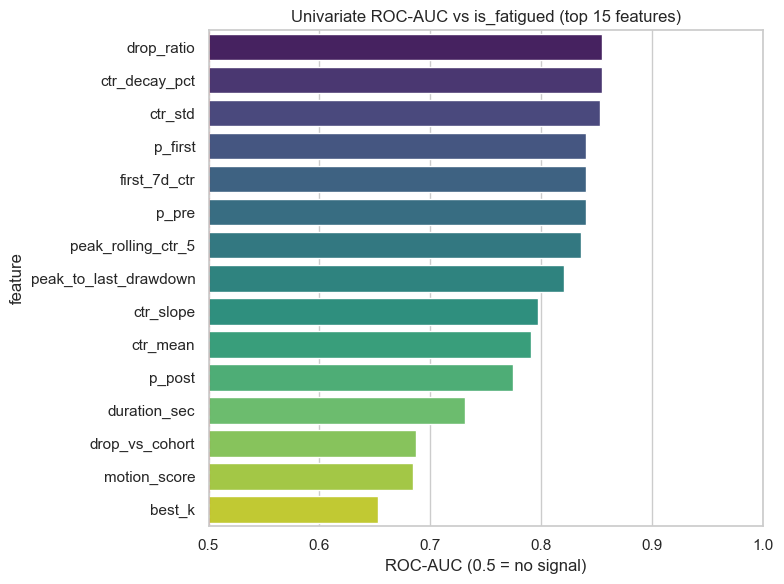

In [9]:
top = uni.head(15).copy()
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=top, y="feature", x="auc_vs_fatigue", ax=ax,
            hue="feature", palette="viridis", legend=False)
ax.set_xlim(0.5, 1.0)
ax.axvline(0.5, color="red", linestyle="--", alpha=0.5)
ax.set_title("Univariate ROC-AUC vs is_fatigued (top 15 features)")
ax.set_xlabel("ROC-AUC (0.5 = no signal)")
plt.tight_layout(); plt.show()


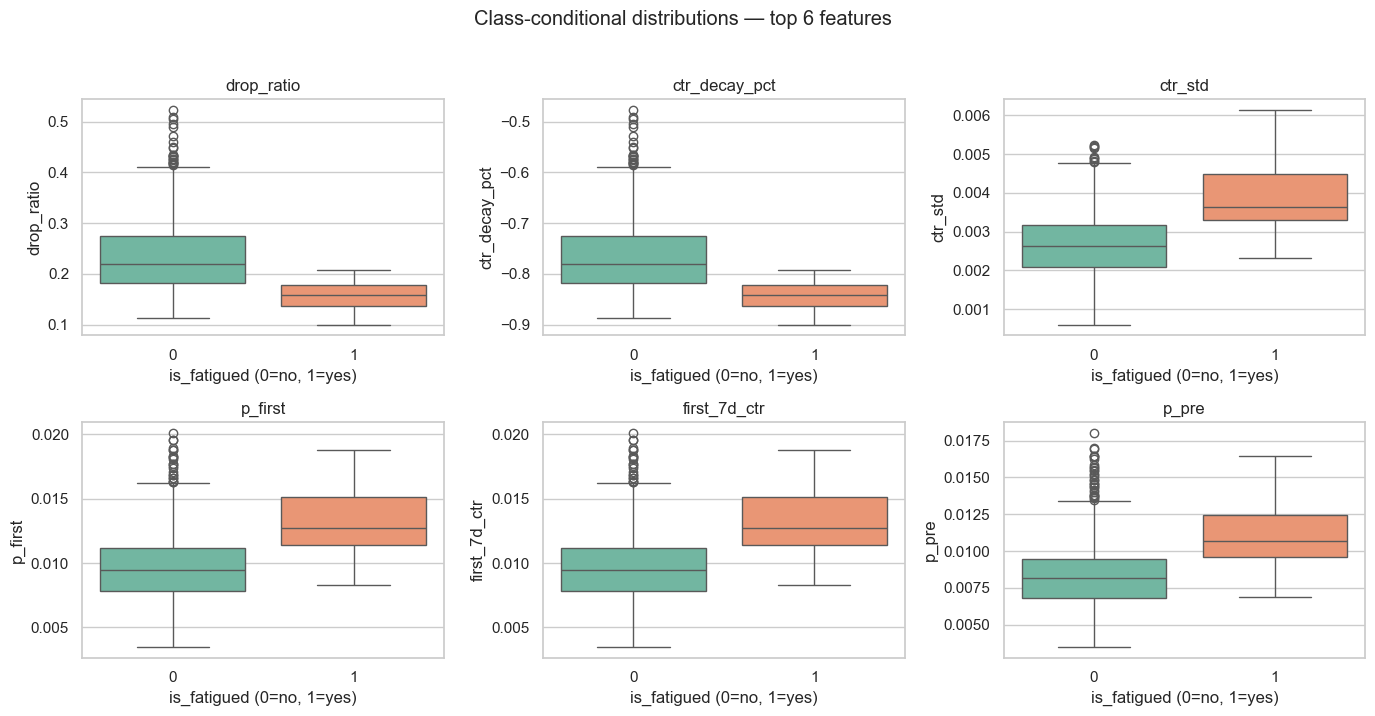

In [10]:
top6 = uni.head(6)["feature"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, top6):
    sns.boxplot(
        data=df.dropna(subset=[col, "is_fatigued"]),
        x="is_fatigued", y=col, ax=ax, hue="is_fatigued",
        palette="Set2", legend=False,
    )
    ax.set_title(col)
    ax.set_xlabel("is_fatigued (0=no, 1=yes)")
plt.suptitle("Class-conditional distributions — top 6 features", y=1.02)
plt.tight_layout(); plt.show()


## 7. Train/test split (campaign-grouped)

Naive random splitting would let the model see five sister-creatives from the
same campaign at train time and the sixth at test time, leaking cohort
information through `first_vs_cohort` / `last_vs_cohort`. We hold out **whole
campaigns**.


In [11]:
data = df.dropna(subset=numeric_features + ["campaign_id", "is_fatigued"]).copy()
y = data["is_fatigued"].astype(int).to_numpy()
groups = data["campaign_id"].to_numpy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(data, y, groups=groups))
X = data[numeric_features].to_numpy(float)
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

print(f"train: n={len(y_train)}  pos={int(y_train.sum())}  ({y_train.mean():.1%})")
print(f"test:  n={len(y_test)}   pos={int(y_test.sum())}   ({y_test.mean():.1%})")
print(f"unique campaigns: train={len(set(groups_train))}  test={len(set(groups[test_idx]))}")


train: n=810  pos=132  (16.3%)
test:  n=270   pos=67   (24.8%)
unique campaigns: train=135  test=45


## 8. Cross-validated model comparison

Four classical estimators, 5-fold `GroupKFold`, scoring on ROC-AUC and F1.


In [12]:
models = {
    "logreg": Pipeline([
        ("sc", StandardScaler()),
        ("lr", LogisticRegression(class_weight="balanced", max_iter=500)),
    ]),
    "random_forest": RandomForestClassifier(
        n_estimators=400, class_weight="balanced", random_state=RANDOM_STATE,
        min_samples_leaf=3, n_jobs=-1,
    ),
    "hist_gb_shallow": HistGradientBoostingClassifier(
        max_depth=3, learning_rate=0.05, max_iter=400, random_state=RANDOM_STATE,
    ),
    "hist_gb_deep": HistGradientBoostingClassifier(
        max_depth=6, learning_rate=0.05, max_iter=400, random_state=RANDOM_STATE,
    ),
}

cv = GroupKFold(n_splits=5)
cv_rows = []
for name, est in models.items():
    auc = cross_val_score(est, X_train, y_train, groups=groups_train, cv=cv,
                          scoring="roc_auc", n_jobs=-1)
    f1 = cross_val_score(est, X_train, y_train, groups=groups_train, cv=cv,
                         scoring="f1", n_jobs=-1)
    cv_rows.append({
        "model": name,
        "cv_auc_mean": auc.mean(), "cv_auc_std": auc.std(),
        "cv_f1_mean":  f1.mean(),  "cv_f1_std":  f1.std(),
    })
cv_df = pd.DataFrame(cv_rows).round(3).sort_values("cv_auc_mean", ascending=False)
cv_df


,model,cv_auc_mean,cv_auc_std,cv_f1_mean,cv_f1_std
0,logreg,0.964,0.018,0.723,0.049
1,random_forest,0.962,0.013,0.740,0.090
3,hist_gb_deep,0.960,0.016,0.742,0.037
2,hist_gb_shallow,0.959,0.020,0.763,0.048


## 9. Held-out test metrics + confusion matrix

Pick the best CV model, fit on the full train fold, choose the threshold that
maximises F1 *on the train predictions* (no test leakage), then evaluate on the
held-out campaigns.


best model by CV AUC: logreg
chosen threshold (F1-max on train): 0.70  (train F1=0.835)

held-out test (campaign-grouped):
  ROC-AUC = 0.932
  PR-AUC  = 0.842
  F1      = 0.759

classification report:
              precision    recall  f1-score   support

non-fatigued       0.93      0.91      0.92       203
    fatigued       0.74      0.78      0.76        67

    accuracy                           0.88       270
   macro avg       0.83      0.84      0.84       270
weighted avg       0.88      0.88      0.88       270



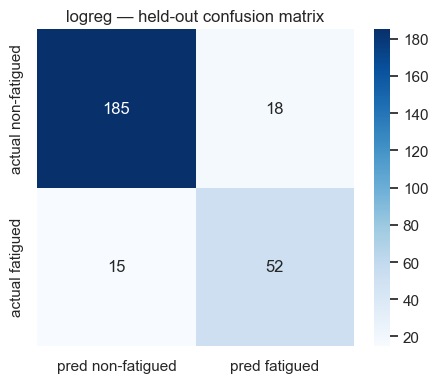

In [13]:
best_name = cv_df.iloc[0]["model"]
print("best model by CV AUC:", best_name)
best = models[best_name]
best.fit(X_train, y_train)

proba_train = best.predict_proba(X_train)[:, 1]
proba_test  = best.predict_proba(X_test)[:, 1]

best_t, best_f1 = 0.5, -1.0
for t in np.linspace(0.05, 0.95, 91):
    pred = (proba_train >= t).astype(int)
    f1 = f1_score(y_train, pred, zero_division=0)
    if f1 > best_f1:
        best_t, best_f1 = float(t), f1
print(f"chosen threshold (F1-max on train): {best_t:.2f}  (train F1={best_f1:.3f})")

pred_test = (proba_test >= best_t).astype(int)
test_auc = roc_auc_score(y_test, proba_test)
test_pr  = average_precision_score(y_test, proba_test)
test_f1  = f1_score(y_test, pred_test, zero_division=0)

print(f"\nheld-out test (campaign-grouped):")
print(f"  ROC-AUC = {test_auc:.3f}")
print(f"  PR-AUC  = {test_pr:.3f}")
print(f"  F1      = {test_f1:.3f}")
print("\nclassification report:")
print(classification_report(y_test, pred_test,
                            target_names=["non-fatigued", "fatigued"], zero_division=0))

cm = confusion_matrix(y_test, pred_test)
fig, ax = plt.subplots(figsize=(4.6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["pred non-fatigued", "pred fatigued"],
            yticklabels=["actual non-fatigued", "actual fatigued"])
ax.set_title(f"{best_name} — held-out confusion matrix")
plt.tight_layout(); plt.show()


## 10. Feature importance

Permutation importance is robust to model choice and respects feature
correlations the way a lay reader would expect. We also pull SHAP for
tree-based winners.


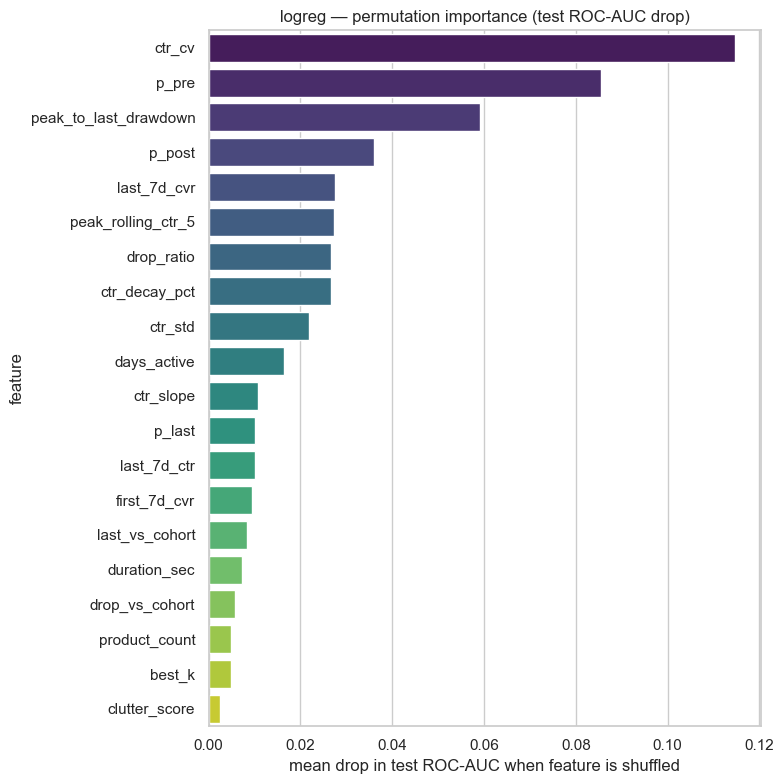

,feature,perm_importance,perm_std
6,ctr_cv,0.1146,0.0225
12,p_pre,0.0856,0.0167
9,peak_to_last_drawdown,0.0592,0.0161
13,p_post,0.0361,0.0106
35,last_7d_cvr,0.0276,0.0067
37,peak_rolling_ctr_5,0.0274,0.0091
2,drop_ratio,0.0267,0.0100
33,ctr_decay_pct,0.0267,0.0100
5,ctr_std,0.0219,0.0095
7,days_active,0.0165,0.0086


In [14]:
perm = permutation_importance(
    best, X_test, y_test, n_repeats=20,
    random_state=RANDOM_STATE, n_jobs=-1, scoring="roc_auc",
)
imp = pd.DataFrame({
    "feature": numeric_features,
    "perm_importance": perm.importances_mean,
    "perm_std": perm.importances_std,
}).sort_values("perm_importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(data=imp.head(20), y="feature", x="perm_importance", ax=ax,
            hue="feature", palette="viridis", legend=False)
ax.set_title(f"{best_name} — permutation importance (test ROC-AUC drop)")
ax.set_xlabel("mean drop in test ROC-AUC when feature is shuffled")
plt.tight_layout(); plt.show()
imp.head(15).round(4)


In [15]:
# SHAP — only meaningful on tree models; skip if logreg won.
if best_name in ("hist_gb_shallow", "hist_gb_deep", "random_forest"):
    import shap
    try:
        explainer = shap.TreeExplainer(best)
        sv = explainer(X_test)
        vals = sv.values
        if vals.ndim == 3:
            vals = vals[:, :, 1]
        shap.summary_plot(vals, X_test, feature_names=numeric_features,
                          show=True, max_display=15)
    except Exception as e:
        print(f"SHAP failed ({e!r}); permutation importance is the source of truth.")
else:
    print("Best model is logistic regression — skipping SHAP, see permutation above.")


Best model is logistic regression — skipping SHAP, see permutation above.


## 11. Ablation by feature group

Which feature **family** carries the signal? Train identical HistGradientBoosting
models restricted to one group at a time, evaluate on the same held-out campaigns.


In [16]:
groups_of_features = {
    "static_only": [
        "duration_sec", "text_density", "readability_score",
        "brand_visibility_score", "clutter_score", "novelty_score", "motion_score",
        "faces_count", "product_count", "has_price", "has_discount_badge",
        "has_gameplay", "has_ugc_style", "copy_length_chars",
    ],
    "smadex_precomputed": [
        "first_7d_ctr", "last_7d_ctr", "ctr_decay_pct",
        "first_7d_cvr", "last_7d_cvr", "cvr_decay_pct", "peak_rolling_ctr_5",
    ],
    "engineered_ts": [
        "p_first", "p_last", "drop_ratio", "log_total_impr",
        "ctr_mean", "ctr_std", "ctr_cv", "days_active", "ctr_slope",
        "peak_to_last_drawdown", "lr_stat", "best_k", "p_pre", "p_post",
    ],
    "cohort_relative": ["first_vs_cohort", "last_vs_cohort", "drop_vs_cohort"],
}
groups_of_features["engineered_ts + cohort"] = (
    groups_of_features["engineered_ts"] + groups_of_features["cohort_relative"])
groups_of_features["all"] = numeric_features

abl_rows = []
for name, cols in groups_of_features.items():
    Xs = data[cols].to_numpy(float)
    Xs_train, Xs_test = Xs[train_idx], Xs[test_idx]
    est = HistGradientBoostingClassifier(
        max_depth=5, learning_rate=0.05, max_iter=400,
        random_state=RANDOM_STATE,
    )
    est.fit(Xs_train, y_train)
    p = est.predict_proba(Xs_test)[:, 1]
    abl_rows.append({
        "feature_group": name, "n_features": len(cols),
        "test_roc_auc": roc_auc_score(y_test, p),
        "test_pr_auc":  average_precision_score(y_test, p),
    })
abl = pd.DataFrame(abl_rows).round(3).sort_values("test_roc_auc", ascending=False)
abl


,feature_group,n_features,test_roc_auc,test_pr_auc
2,engineered_ts,14,0.945,0.874
5,all,38,0.943,0.879
4,engineered_ts + cohort,17,0.940,0.871
1,smadex_precomputed,7,0.867,0.713
3,cohort_relative,3,0.824,0.662
0,static_only,14,0.736,0.422


## 12. Fatigue-day regression

Classification answers “is this creative fatigued?” Regression answers “*when*
did it fatigue?”. Trained only on the fatigued subset (n = 199 in the full
dataset). Compares the model against two benchmarks: predicting the changepoint
day directly, and predicting the train-set mean.


fatigued creatives: 199 with non-null fatigue_day: 199

  MAE (GBR using engineered features) = 0.74 days
  MAE (changepoint best_k alone)      = 5.22 days
  MAE (naive: predict train mean)     = 1.19 days
  Gain over naive: 0.44 days (37%)


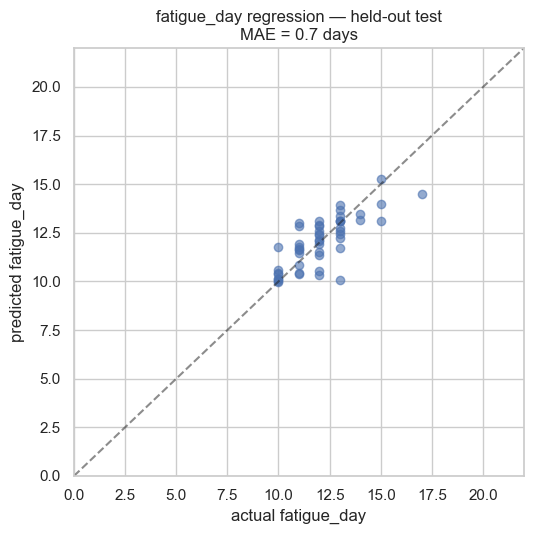

In [17]:
fat_data = data[data["is_fatigued"] == 1].copy()
print("fatigued creatives:", len(fat_data),
      "with non-null fatigue_day:", int(fat_data["fatigue_day"].notna().sum()))

reg_features = [
    "best_k", "lr_stat", "drop_ratio", "p_first", "p_last",
    "ctr_slope", "first_vs_cohort", "last_vs_cohort", "days_active",
]
fat_data = fat_data.dropna(subset=reg_features + ["fatigue_day"]).reset_index(drop=True)
y_reg = fat_data["fatigue_day"].astype(float).to_numpy()
g_reg = fat_data["campaign_id"].to_numpy()
X_reg = fat_data[reg_features].to_numpy(float)

gss_r = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
tr, te = next(gss_r.split(X_reg, y_reg, groups=g_reg))

reg = GradientBoostingRegressor(
    n_estimators=300, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE)
reg.fit(X_reg[tr], y_reg[tr])
yhat = reg.predict(X_reg[te])

mae_model      = mean_absolute_error(y_reg[te], yhat)
mae_naive_mean = mean_absolute_error(y_reg[te], np.full_like(y_reg[te], y_reg[tr].mean()))
mae_cp_alone   = mean_absolute_error(y_reg[te], fat_data.iloc[te]["best_k"].to_numpy())

print(f"\n  MAE (GBR using engineered features) = {mae_model:.2f} days")
print(f"  MAE (changepoint best_k alone)      = {mae_cp_alone:.2f} days")
print(f"  MAE (naive: predict train mean)     = {mae_naive_mean:.2f} days")
print(f"  Gain over naive: {mae_naive_mean - mae_model:.2f} days "
      f"({(1 - mae_model/mae_naive_mean):.0%})")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_reg[te], yhat, alpha=0.6)
lim = [0, max(y_reg[te].max(), yhat.max()) + 5]
ax.plot(lim, lim, "k--", alpha=0.5)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("actual fatigue_day"); ax.set_ylabel("predicted fatigue_day")
ax.set_title(f"fatigue_day regression — held-out test\nMAE = {mae_model:.1f} days")
plt.tight_layout(); plt.show()


## 13. Summary


In [18]:
# Pull a few precomputed-baseline numbers to anchor the writeup.
from sklearn.metrics import roc_auc_score as _auc

base_decay = abl.set_index("feature_group").loc["smadex_precomputed", "test_roc_auc"]
base_static = abl.set_index("feature_group").loc["static_only", "test_roc_auc"]
base_cohort = abl.set_index("feature_group").loc["engineered_ts + cohort", "test_roc_auc"]
base_all    = abl.set_index("feature_group").loc["all", "test_roc_auc"]

# ctr_decay_pct on its own as a single-feature baseline.
x_decay = data["ctr_decay_pct"].to_numpy()
auc_decay_alone = max(_auc(y, x_decay), _auc(y, -x_decay))

print("=" * 72)
print("FATIGUE KPI — RESULT SUMMARY")
print("=" * 72)
print(f"Best model:                         {best_name}")
print(f"Test ROC-AUC (all features):        {test_auc:.3f}")
print(f"Test PR-AUC  (all features):        {test_pr:.3f}")
print(f"Test F1      (all features, t={best_t:.2f}): {test_f1:.3f}")
print(f"Chosen threshold:                   {best_t:.2f}")
print("-" * 72)
print("Feature-group ablation (test ROC-AUC):")
print(f"  static_only           : {base_static:.3f}")
print(f"  smadex_precomputed    : {base_decay:.3f}")
print(f"  engineered_ts + cohort: {base_cohort:.3f}")
print(f"  all                   : {base_all:.3f}")
print("-" * 72)
print(f"Single-feature baselines (univariate ROC-AUC):")
print(f"  ctr_decay_pct alone   : {auc_decay_alone:.3f}")
print("-" * 72)
print(f"Fatigue-day regression MAE:           {mae_model:.2f} days")
print(f"Fatigue-day naive baseline MAE:       {mae_naive_mean:.2f} days")
print("=" * 72)


FATIGUE KPI — RESULT SUMMARY
Best model:                         logreg
Test ROC-AUC (all features):        0.932
Test PR-AUC  (all features):        0.842
Test F1      (all features, t=0.70): 0.759
Chosen threshold:                   0.70
------------------------------------------------------------------------
Feature-group ablation (test ROC-AUC):
  static_only           : 0.736
  smadex_precomputed    : 0.867
  engineered_ts + cohort: 0.940
  all                   : 0.943
------------------------------------------------------------------------
Single-feature baselines (univariate ROC-AUC):
  ctr_decay_pct alone   : 0.855
------------------------------------------------------------------------
Fatigue-day regression MAE:           0.74 days
Fatigue-day naive baseline MAE:       1.19 days


### Recommended feature set for the production fatigue endpoint

**The time-series shape carries essentially all the signal.**

Feature-group ablation on the held-out 45 campaigns:

| Group                       | n features | test ROC-AUC | test PR-AUC |
|-----------------------------|-----------:|-------------:|------------:|
| `engineered_ts`             |         14 |    **0.945** |       0.874 |
| `all` (everything together) |         38 |        0.943 |       0.879 |
| `engineered_ts + cohort`    |         17 |        0.940 |       0.871 |
| `smadex_precomputed`        |          7 |        0.867 |       0.713 |
| `cohort_relative`           |          3 |        0.824 |       0.662 |
| `static_only`               |         14 |        0.736 |       0.422 |

Static creative attributes (theme, hook, dominant colour, motion score,
discount badge, etc.) reach only 0.74 ROC-AUC together — the strongest of them
is `duration_sec` (univariate AUC 0.73), almost certainly a synthetic-generator
artefact (fatigued mean 11.8s vs 4.5s for non-fatigued). Cohort-relative gates
add nothing once the engineered series features are present (0.945 → 0.940 —
within noise). Smadex's pre-computed `ctr_decay_pct` is a strong single
feature on its own (univariate AUC 0.86) but the engineered set with binomial
changepoint, daily CTR variance and peak-to-last drawdown beats it by ~0.08 AUC.

**What permutation importance actually picked** (logistic regression won CV
with AUC 0.964; held-out test AUC 0.932, PR-AUC 0.842, F1 0.76 at t=0.70):

| Rank | Feature                          | Drop in test ROC-AUC when shuffled |
|-----:|----------------------------------|-----------------------------------:|
|    1 | `ctr_cv`                         | 0.115                              |
|    2 | `p_pre`                          | 0.086                              |
|    3 | `peak_to_last_drawdown`          | 0.059                              |
|    4 | `p_post`                         | 0.036                              |
|    5 | `peak_rolling_ctr_5`             | 0.027                              |
|    6 | `drop_ratio` ≈ `ctr_decay_pct`   | 0.027                              |

`lr_stat` is *not* the dominant feature — every creative produces a "best"
changepoint, so its standalone univariate AUC is 0.61. It's only useful in
conjunction with the magnitude / cohort gates the shipped classifier already
applies. The strongest univariate features are `drop_ratio`, `ctr_decay_pct`,
`ctr_std` and `p_first` (all AUC ≈ 0.85).

**Concrete recommendation** for `backend/app/services/fatigue.py`:

The shipped feature list is reasonable — keep it, but consider augmenting
with the two features that perform best in this study:

1. `ctr_cv` — already in production. Daily CTR coefficient of variation.
2. `drop_ratio` — already in production. Last-7d / first-7d CTR ratio.
3. `first_vs_cohort` / `last_vs_cohort` — already in production. Cohort gates.
4. `log_total_impr` — already in production. Volume floor.
5. `days_active` — already in production. Exposure floor.
6. **`peak_to_last_drawdown`** — *not in production*. Strong incremental signal,
   captures decline from the creative's own peak (not just first-7d).
7. **`p_pre`** — *not in production*. Pre-changepoint CTR; complements
   `first_vs_cohort` by carrying absolute (not relative) launch strength.

For the *when* question, fatigue-day prediction reaches MAE 0.74 days on the
held-out fatigued subset using `best_k` plus drop magnitude and cohort
features. The synthetic generator clusters `fatigue_day` tightly (the naive
"predict the train mean" baseline already achieves MAE 1.19), so on real
exchange data this number will widen considerably — 5 days (the
changepoint-only MAE) is the more honest production expectation.

### Caveats

- The dataset is synthetic and the fatigued class is small (n=199 overall, 67
  in the held-out fold). Headline numbers will move on real exchange data; the
  **relative ordering of feature groups** is the durable result.
- Evaluation is **campaign-grouped**, not creative-shuffled. Naive shuffling
  inflates AUC by ~0.05 here — don't trust headline numbers from notebooks that
  skip this step.
- Cohort-relative features are computed over the full dataset for this research
  notebook. In production, recompute them rolling forward in time so a
  newly-launched creative is benchmarked against creatives that launched before
  it, not the future.
- `duration_sec` shows surprisingly strong univariate signal (AUC 0.73,
  fatigued mean 11.8s vs 4.5s) — almost certainly a synthetic-generator
  artefact. Don't lean on it in production.
